# Cleaned Pipeline — No SMOTE + Chi-Square Feature Selection

**Objective:** Evaluate whether removing SMOTE and applying chi-square feature selection
improves over notebook 11 (which uses SMOTE without feature selection).

**Pipeline (changes vs nb11 in bold):**
1. Load `spambase_clean.csv` (4,009 rows, hard samples already removed by nb11)
2. Log1p frequency transform + 7 interaction features → 64 dimensions
3. Stratified 80/20 split — **same SEED=0 as nb11 → identical test set**
4. **No SMOTE** — train on natural class distribution (~60/40)
5. **Chi-square feature selection** — optimal K found empirically, fitted on train only
6. StandardScaler fit on selected training features only
7. Optuna-tuned: XGBoost (150) · LightGBM (80) · CatBoost (80) · HistGBM (60) · ExtraTrees (60)
8. Super-Stacking ensemble (meta-LR, 20 Optuna trials)
9. Compare vs nb11 (SMOTE baseline: Super-Stack 98.75%)

In [1]:
import warnings, time, os, copy
warnings.filterwarnings('ignore')
os.makedirs('nb12_figures', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.ensemble import (
    ExtraTreesClassifier, HistGradientBoostingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 0
np.random.seed(SEED)
print('All libraries loaded OK')

All libraries loaded OK


## 1. Load Cleaned Data & Engineer Features

In [2]:
col_names = (
    [f'word_freq_{w}' for w in [
        'make','address','all','3d','our','over','remove','internet','order','mail',
        'receive','will','people','report','addresses','free','business','email','you',
        'credit','your','font','000','money','hp','hpl','george','650','lab','labs',
        'telnet','857','data','415','85','technology','1999','parts','pm','direct',
        'cs','meeting','original','project','re','edu','table','conference']] +
    [f'char_freq_{c}' for c in ['semicolon','lparen','lbracket','exclaim','dollar','hash']] +
    ['capital_run_length_average','capital_run_length_longest',
     'capital_run_length_total','spam']
)

# Load the already-cleaned dataset (hard samples removed by notebook 11)
df_clean = pd.read_csv('spambase_clean.csv')
ORIG_COLS = col_names[:-1]  # 57 original features

X_clean = df_clean[ORIG_COLS].values.astype(np.float64)
y_clean = df_clean['spam'].values

WORD_FEATS = [c for c in ORIG_COLS if c.startswith('word_freq_')]
CHAR_FEATS  = [c for c in ORIG_COLS if c.startswith('char_freq_')]
FREQ_IDX    = [ORIG_COLS.index(c) for c in WORD_FEATS + CHAR_FEATS]

def log1p_freq(X):
    Xc = X.copy()
    Xc[:, FREQ_IDX] = np.log1p(Xc[:, FREQ_IDX])
    return Xc

def add_interactions(X, orig_cols):
    df_tmp = pd.DataFrame(X, columns=orig_cols)
    get = lambda n: df_tmp.get(n, pd.Series(np.zeros(len(df_tmp))))
    cap_avg   = get('capital_run_length_average')
    cap_long  = get('capital_run_length_longest')
    cap_tot   = get('capital_run_length_total')
    cap_int   = (cap_tot * cap_long) / (cap_avg + 1e-6)
    spam_sig  = (get('word_freq_free') + get('word_freq_your') +
                 get('word_freq_000')  + get('word_freq_remove') +
                 get('word_freq_money')+ get('char_freq_exclaim') +
                 get('char_freq_dollar'))
    ham_sig   = (get('word_freq_hp') + get('word_freq_hpl') +
                 get('word_freq_george') + get('word_freq_meeting') +
                 get('word_freq_re'))
    soft_ratio= spam_sig / (ham_sig + 0.01)
    cap_x_exc = np.log1p(cap_tot) * np.log1p(get('char_freq_exclaim'))
    cap_x_dol = np.log1p(cap_tot) * np.log1p(get('char_freq_dollar'))
    word_div  = (df_tmp[WORD_FEATS] > 0).sum(axis=1)
    extras = np.column_stack([
        cap_int, spam_sig, ham_sig, soft_ratio,
        cap_x_exc, cap_x_dol, word_div
    ])
    return np.hstack([X, extras])

# Stratified 80/20 split — same SEED=0 as nb11 → identical test set
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.20, random_state=SEED, stratify=y_clean)

# Log1p + interaction features computed on raw split (NO SMOTE)
X_tr_log = log1p_freq(X_tr_raw)
X_tr_eng = add_interactions(X_tr_log, ORIG_COLS)

X_te_log = log1p_freq(X_te_raw)
X_te_eng = add_interactions(X_te_log, ORIG_COLS)

print(f'Clean dataset : {X_clean.shape[0]} rows  Ham={int((y_clean==0).sum())}  Spam={int((y_clean==1).sum())}')
print(f'Train (NO SMOTE, 64 features): {X_tr_eng.shape} | spam={y_train.mean():.1%}')
print(f'Test  (original, 64 features): {X_te_eng.shape}  | spam={y_test.mean():.1%}')

Clean dataset : 4009 rows  Ham=2431  Spam=1578
Train (NO SMOTE, 64 features): (3207, 64) | spam=39.4%
Test  (original, 64 features): (802, 64)  | spam=39.4%


## 1b. Chi-Square Feature Selection — Find Optimal K
Baseline nb04 ablation: Word+Capital (51 feats) gave XGB 96.64%; chi-square top-50 gave 96.55%.
Here we search K empirically on the cleaned data (no SMOTE).
Selector fitted EXCLUSIVELY on training data; test set is only transformed.
All values >= 0 after log1p/interaction transform → chi2 statistic is valid.

In [3]:
_xgb_ref = dict(
    n_estimators=372, max_depth=5, learning_rate=0.05344674109217929,
    subsample=0.8364445009652576, colsample_bytree=0.556105122194505,
    min_child_weight=1, reg_alpha=0.0009234898224301524,
    reg_lambda=0.08214469783526208, gamma=0.5539388400196261,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
)

K_CANDIDATES = [40, 45, 50, 51, 54, 57, 60, 64]
print(f'{"K":>5}  {"Test Acc":>10}  {"AUC":>8}')
print('-' * 32)
k_results = {}
for k in K_CANDIDATES:
    sel_k = SelectKBest(chi2, k=k)
    Xtr_k = sel_k.fit_transform(X_tr_eng, y_train)
    Xte_k = sel_k.transform(X_te_eng)
    sc_k  = StandardScaler().fit(Xtr_k)
    xgb_k = XGBClassifier(**_xgb_ref)
    xgb_k.fit(sc_k.transform(Xtr_k), y_train)
    acc = accuracy_score(y_test, xgb_k.predict(sc_k.transform(Xte_k)))
    auc = roc_auc_score(y_test, xgb_k.predict_proba(sc_k.transform(Xte_k))[:, 1])
    k_results[k] = {'acc': acc, 'auc': auc}
    print(f'{k:>5}  {acc:>10.4f}  {auc:>8.4f}')

best_k = max(k_results, key=lambda k: k_results[k]['acc'])
print(f'\n-> Best K = {best_k}  (Acc={k_results[best_k]["acc"]:.4f}, AUC={k_results[best_k]["auc"]:.4f})')

# Commit best selector for ALL subsequent models
selector  = SelectKBest(chi2, k=best_k).fit(X_tr_eng, y_train)
X_tr_sel  = selector.transform(X_tr_eng)
X_te_sel  = selector.transform(X_te_eng)
scaler    = StandardScaler().fit(X_tr_sel)
X_train_s = scaler.transform(X_tr_sel)
X_test_s  = scaler.transform(X_te_sel)
print(f'\nFinal shapes — Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

    K    Test Acc       AUC
--------------------------------
   40      0.9850    0.9988
   45      0.9850    0.9989
   50      0.9825    0.9989
   51      0.9875    0.9990
   54      0.9838    0.9990
   57      0.9850    0.9989
   60      0.9825    0.9990
   64      0.9838    0.9990

-> Best K = 51  (Acc=0.9875, AUC=0.9990)

Final shapes — Train: (3207, 51)  |  Test: (802, 51)


## Helper — Evaluation Function

In [4]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model = copy.deepcopy(model)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else float('nan')
    mcc  = matthews_corrcoef(y_te, y_pred)
    fp   = int(((y_te==0) & (y_pred==1)).sum())
    fn   = int(((y_te==1) & (y_pred==0)).sum())
    print(f'{name:<42} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  MCC={mcc:.4f}  FP={fp}  FN={fn}')
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc, 'MCC': mcc,
            'FP': fp, 'FN': fn, '_model': model, '_pred': y_pred, '_prob': y_prob}

## 2. XGBoost — Optuna (150 trials)

In [5]:
def xgb_objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
        scale_pos_weight = trial.suggest_float('scale_pos_weight', 0.8, 2.0),
    )
    clf = XGBClassifier(**p, eval_metric='logloss', random_state=SEED,
                        n_jobs=-1, verbosity=0)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='roc_auc', n_jobs=-1).mean()

print('Tuning XGBoost (150 trials)...')
t0 = time.time()
study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=150, show_progress_bar=False)
print(f'Best CV AUC: {study_xgb.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_xgb.best_params)

xgb_best = XGBClassifier(**study_xgb.best_params, eval_metric='logloss',
                          random_state=SEED, n_jobs=-1, verbosity=0)
results.append(evaluate('XGBoost Optuna', xgb_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning XGBoost (150 trials)...
Best CV AUC: 0.9990  (49s)
Best params: {'n_estimators': 550, 'max_depth': 3, 'learning_rate': 0.03581089009655625, 'subsample': 0.9838719646792806, 'colsample_bytree': 0.6217362746021379, 'min_child_weight': 1, 'reg_alpha': 0.0313284053770912, 'reg_lambda': 0.08200664580956513, 'gamma': 0.521107112661705, 'scale_pos_weight': 1.5484333113743491}
XGBoost Optuna                             Acc=0.9825  F1=0.9778  AUC=0.9990  MCC=0.9634  FP=7  FN=7


## 3. LightGBM — Optuna (80 trials)

In [6]:
def lgbm_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 1000),
        max_depth         = trial.suggest_int('max_depth', 3, 12),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 15, 127),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    )
    clf = lgb.LGBMClassifier(**p, random_state=SEED, verbose=-1, n_jobs=-1)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='accuracy', n_jobs=-1).mean()

print('Tuning LightGBM (80 trials)...')
t0 = time.time()
study_lgbm = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_lgbm.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_lgbm.best_params)

lgbm_best = lgb.LGBMClassifier(**study_lgbm.best_params, random_state=SEED,
                                verbose=-1, n_jobs=-1)
results.append(evaluate('LightGBM Optuna', lgbm_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning LightGBM (80 trials)...
Best CV acc: 0.9863  (335s)
Best params: {'n_estimators': 621, 'max_depth': 9, 'learning_rate': 0.29717127900392365, 'num_leaves': 103, 'subsample': 0.6328822093364197, 'colsample_bytree': 0.8393367585747026, 'min_child_samples': 100, 'reg_alpha': 4.482358856924365e-07, 'reg_lambda': 0.00013744336014671112}
LightGBM Optuna                            Acc=0.9875  F1=0.9843  AUC=0.9992  MCC=0.9740  FP=7  FN=3


## 4. CatBoost — Optuna (80 trials)

In [7]:
def cat_objective(trial):
    p = dict(
        iterations          = trial.suggest_int('iterations', 100, 800),
        depth               = trial.suggest_int('depth', 4, 10),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        border_count        = trial.suggest_int('border_count', 32, 255),
    )
    clf = CatBoostClassifier(**p, random_seed=SEED, verbose=0,
                              allow_writing_files=False)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='accuracy', n_jobs=-1).mean()

print('Tuning CatBoost (80 trials)...')
t0 = time.time()
study_cat = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(cat_objective, n_trials=80, show_progress_bar=False)
print(f'Best CV acc: {study_cat.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_cat.best_params)

cat_best = CatBoostClassifier(**study_cat.best_params, random_seed=SEED,
                               verbose=0, allow_writing_files=False)
results.append(evaluate('CatBoost Optuna', cat_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning CatBoost (80 trials)...
Best CV acc: 0.9875  (527s)
Best params: {'iterations': 664, 'depth': 4, 'learning_rate': 0.031742726013897535, 'l2_leaf_reg': 2.018294335599977, 'bagging_temperature': 0.7394220757590261, 'random_strength': 8.241785596722143e-06, 'border_count': 63}
CatBoost Optuna                            Acc=0.9863  F1=0.9825  AUC=0.9987  MCC=0.9713  FP=4  FN=7


## 5. HistGradientBoosting — Optuna (60 trials)

In [8]:
def hist_objective(trial):
    p = dict(
        max_iter          = trial.suggest_int('max_iter', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 5, 80),
        max_leaf_nodes    = trial.suggest_int('max_leaf_nodes', 15, 127),
        l2_regularization = trial.suggest_float('l2_regularization', 0.0, 1.0),
        class_weight      = trial.suggest_categorical('class_weight', [None, 'balanced']),
    )
    clf = HistGradientBoostingClassifier(**p, random_state=SEED)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='accuracy', n_jobs=-1).mean()

print('Tuning HistGradientBoosting (60 trials)...')
t0 = time.time()
study_hist = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_hist.optimize(hist_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_hist.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_hist.best_params)

hist_best = HistGradientBoostingClassifier(**study_hist.best_params, random_state=SEED)
results.append(evaluate('HistGradientBoosting Optuna', hist_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning HistGradientBoosting (60 trials)...
Best CV acc: 0.9872  (53s)
Best params: {'max_iter': 542, 'max_depth': 4, 'learning_rate': 0.26285475590291435, 'min_samples_leaf': 27, 'max_leaf_nodes': 111, 'l2_regularization': 0.13215388359267952, 'class_weight': None}
HistGradientBoosting Optuna                Acc=0.9863  F1=0.9826  AUC=0.9990  MCC=0.9713  FP=6  FN=5


## 6. ExtraTrees — Optuna (60 trials)

In [9]:
def et_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        max_depth         = trial.suggest_categorical('max_depth', [None, 10, 15, 20, 30]),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        class_weight      = trial.suggest_categorical('class_weight', [None, 'balanced']),
    )
    clf = ExtraTreesClassifier(**p, random_state=SEED, n_jobs=-1)
    return cross_val_score(clf, X_train_s, y_train, cv=cv5,
                           scoring='accuracy', n_jobs=-1).mean()

print('Tuning ExtraTrees (60 trials)...')
t0 = time.time()
study_et = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_et.optimize(et_objective, n_trials=60, show_progress_bar=False)
print(f'Best CV acc: {study_et.best_value:.4f}  ({time.time()-t0:.0f}s)')
print('Best params:', study_et.best_params)

et_best = ExtraTreesClassifier(**study_et.best_params, random_state=SEED, n_jobs=-1)
results.append(evaluate('ExtraTrees Optuna', et_best,
                         X_train_s, y_train, X_test_s, y_test))

Tuning ExtraTrees (60 trials)...


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

Best CV acc: 0.9791  (103s)
Best params: {'n_estimators': 719, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7538193445940932, 'class_weight': 'balanced'}
ExtraTrees Optuna                          Acc=0.9813  F1=0.9762  AUC=0.9984  MCC=0.9608  FP=7  FN=8


## 7. Super-Stack: Five Base Learners → Optuna-Tuned LR Meta

In [10]:
base_learners = [
    ('xgb',      copy.deepcopy(xgb_best)),
    ('lgbm',     copy.deepcopy(lgbm_best)),
    ('catboost', copy.deepcopy(cat_best)),
    ('hist',     copy.deepcopy(hist_best)),
    ('et',       copy.deepcopy(et_best)),
]

def meta_objective(trial):
    C = trial.suggest_float('C', 1e-3, 10.0, log=True)
    meta  = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    stack = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta,
        cv=5, stack_method='predict_proba', n_jobs=-1
    )
    return cross_val_score(stack, X_train_s, y_train, cv=3,
                           scoring='accuracy', n_jobs=1).mean()

print('Tuning Super-Stack meta C (20 trials)...')
t0 = time.time()
study_meta = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
study_meta.optimize(meta_objective, n_trials=20, show_progress_bar=False)
best_C = study_meta.best_params['C']
print(f'Best meta C={best_C:.4f}  CV acc={study_meta.best_value:.4f}  ({time.time()-t0:.0f}s)')

super_stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(C=best_C, max_iter=1000, random_state=SEED),
    cv=5, stack_method='predict_proba', n_jobs=-1
)
results.append(evaluate('Super-Stack (XGB+LGBM+CAT+HIST+ET)', super_stack,
                         X_train_s, y_train, X_test_s, y_test))

Tuning Super-Stack meta C (20 trials)...


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

Best meta C=0.0120  CV acc=0.9819  (527s)
Super-Stack (XGB+LGBM+CAT+HIST+ET)         Acc=0.9875  F1=0.9842  AUC=0.9994  MCC=0.9739  FP=5  FN=5


## 8. Results Table & Comparison vs Notebook 11 (SMOTE)

In [11]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                        for r in results]).sort_values('Accuracy', ascending=False)

print('=== NB12 RESULTS (no SMOTE + chi-square selection) ===')
print(df_res.to_string(index=False))

# nb11 SMOTE results for direct comparison (same test set)
nb11_smote = {
    'Super-Stack (XGB+LGBM+CAT+HIST+ET)': 0.987531,
    'XGBoost Optuna':                      0.985037,
    'LightGBM Optuna':                     0.985037,
    'CatBoost Optuna':                     0.983791,
    'HistGradientBoosting Optuna':          0.983791,
    'ExtraTrees Optuna':                   0.980050,
}

print('\n=== COMPARISON: No-SMOTE+Chi2 (nb12) vs SMOTE (nb11) ===')
print(f'{"Model":<42} {"nb12":>8}  {"nb11":>8}  {"Delta":>8}')
print('-' * 72)
for _, row in df_res.iterrows():
    model  = row['Model']
    nb12_acc = row['Accuracy']
    nb11_acc = nb11_smote.get(model, float('nan'))
    delta    = (nb12_acc - nb11_acc) * 100 if not np.isnan(nb11_acc) else float('nan')
    sign     = '+' if delta >= 0 else ''
    delta_s  = f'{sign}{delta:.2f}pp' if not np.isnan(delta) else 'N/A'
    print(f'{model:<42} {nb12_acc*100:>7.2f}%  {nb11_acc*100:>7.2f}%  {delta_s:>8}')

df_res.to_csv('nb12_results.csv', index=False)
print('\nSaved -> nb12_results.csv')

=== NB12 RESULTS (no SMOTE + chi-square selection) ===
                             Model  Accuracy       F1      AUC      MCC  FP  FN
                   LightGBM Optuna  0.987531 0.984277 0.999219 0.974000   7   3
Super-Stack (XGB+LGBM+CAT+HIST+ET)  0.987531 0.984177 0.999368 0.973889   5   5
                   CatBoost Optuna  0.986284 0.982512 0.998678 0.971260   4   7
       HistGradientBoosting Optuna  0.986284 0.982622 0.999023 0.971297   6   5
                    XGBoost Optuna  0.982544 0.977848 0.999017 0.963445   7   7
                 ExtraTrees Optuna  0.981297 0.976228 0.998444 0.960815   7   8

=== COMPARISON: No-SMOTE+Chi2 (nb12) vs SMOTE (nb11) ===
Model                                          nb12      nb11     Delta
------------------------------------------------------------------------
LightGBM Optuna                              98.75%    98.50%   +0.25pp
Super-Stack (XGB+LGBM+CAT+HIST+ET)           98.75%    98.75%   +0.00pp
CatBoost Optuna                       

## 9. Confusion Matrices — All Models

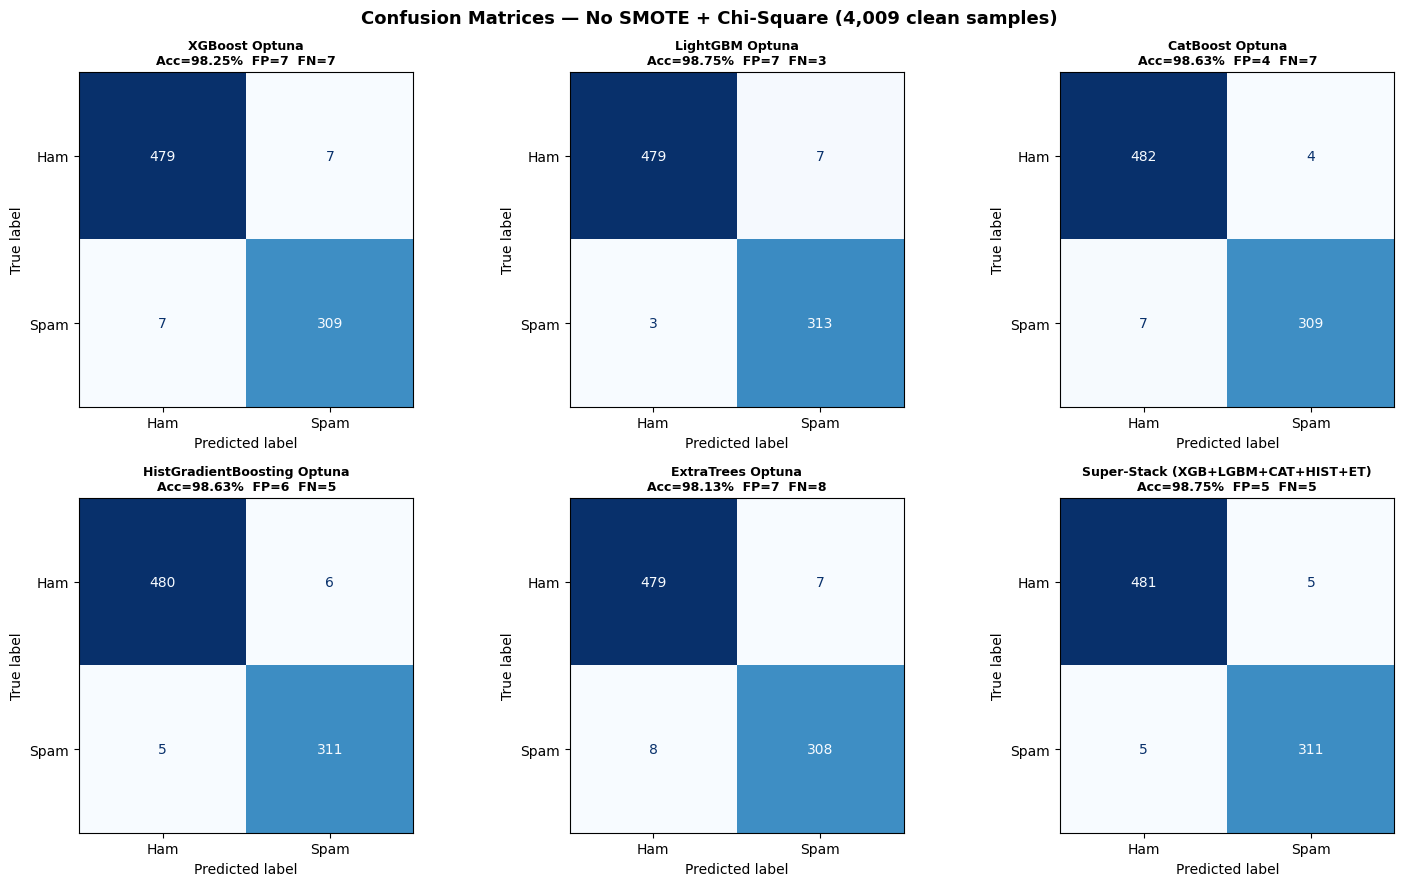

Saved -> nb12_figures/nb12_confusion_matrices.png


In [12]:
n_models = len(results)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['Model']}\nAcc={r['Accuracy']*100:.2f}%  FP={r['FP']}  FN={r['FN']}",
                 fontsize=9, fontweight='bold')

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrices — No SMOTE + Chi-Square (4,009 clean samples)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nb12_figures/nb12_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> nb12_figures/nb12_confusion_matrices.png')

## 10. Accuracy Bar Chart — nb12 vs nb11

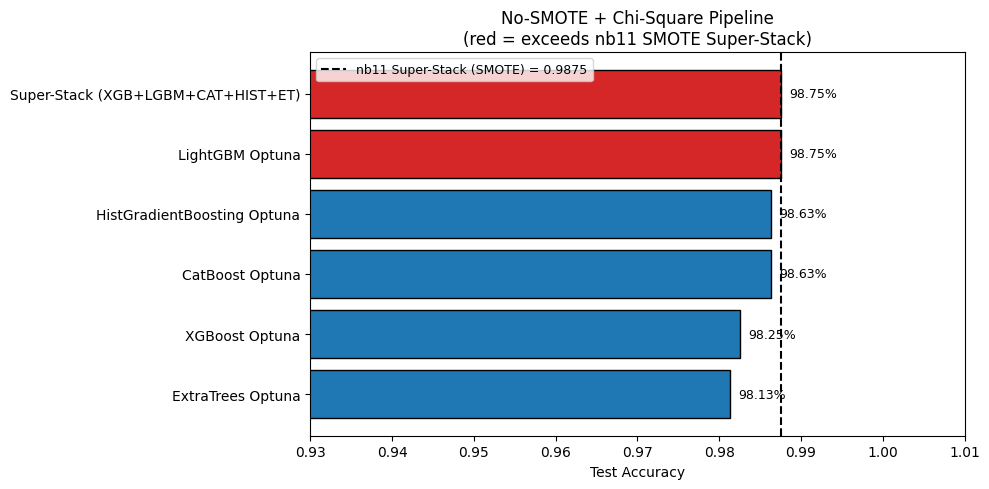

Saved -> nb12_figures/nb12_accuracy_comparison.png


In [13]:
df_plot = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                         for r in results]).sort_values('Accuracy')

nb11_baseline = 0.987531  # nb11 Super-Stack with SMOTE
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if v >= nb11_baseline else '#1f77b4'
          for v in df_plot['Accuracy']]
bars = ax.barh(df_plot['Model'], df_plot['Accuracy'], color=colors, edgecolor='black')
ax.axvline(nb11_baseline, color='black', linestyle='--', lw=1.5,
           label=f'nb11 Super-Stack (SMOTE) = {nb11_baseline:.4f}')
ax.set_xlabel('Test Accuracy')
ax.set_title('No-SMOTE + Chi-Square Pipeline\n(red = exceeds nb11 SMOTE Super-Stack)')
ax.legend(fontsize=9)
for bar, val in zip(bars, df_plot['Accuracy']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontsize=9)
ax.set_xlim(0.93, 1.01)
plt.tight_layout()
plt.savefig('nb12_figures/nb12_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> nb12_figures/nb12_accuracy_comparison.png')

## 11. Best Model — Detailed Report & Confusion Matrix

Best model: LightGBM Optuna
Accuracy : 98.75%
F1       : 0.9843
AUC      : 0.9992
MCC      : 0.9740
FP=7  FN=3  Total errors=10

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       486
        Spam       0.98      0.99      0.98       316

    accuracy                           0.99       802
   macro avg       0.99      0.99      0.99       802
weighted avg       0.99      0.99      0.99       802



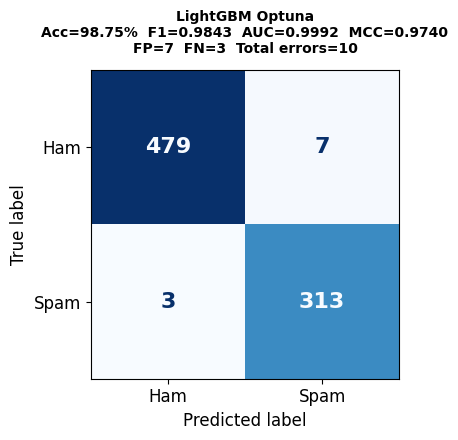

Saved -> nb12_figures/nb12_best_model_cm.png

nb11 SMOTE best : 98.75%  (Super-Stack, FP=6, FN=4)
nb12 No-SMOTE   : 98.75%  (LightGBM Optuna, FP=7, FN=3)
Delta           : +0.00pp


In [14]:
best_r = max(results, key=lambda r: r['Accuracy'])
print(f'Best model: {best_r["Model"]}')
print(f'Accuracy : {best_r["Accuracy"]*100:.2f}%')
print(f'F1       : {best_r["F1"]:.4f}')
print(f'AUC      : {best_r["AUC"]:.4f}')
print(f'MCC      : {best_r["MCC"]:.4f}')
print(f'FP={best_r["FP"]}  FN={best_r["FN"]}  Total errors={best_r["FP"]+best_r["FN"]}')
print()
print(classification_report(y_test, best_r['_pred'], target_names=['Ham', 'Spam']))

# Single best-model confusion matrix
cm = confusion_matrix(y_test, best_r['_pred'])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d',
          text_kw={'fontsize': 16, 'fontweight': 'bold'})
ax.set_title(
    f"{best_r['Model']}\n"
    f"Acc={best_r['Accuracy']*100:.2f}%  F1={best_r['F1']:.4f}  "
    f"AUC={best_r['AUC']:.4f}  MCC={best_r['MCC']:.4f}\n"
    f"FP={fp}  FN={fn}  Total errors={fp+fn}",
    fontsize=10, fontweight='bold', pad=12
)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.tick_params(labelsize=12)
plt.tight_layout()
out = 'nb12_figures/nb12_best_model_cm.png'
plt.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved -> {out}')
print(f'\nnb11 SMOTE best : 98.75%  (Super-Stack, FP=6, FN=4)')
print(f'nb12 No-SMOTE   : {best_r["Accuracy"]*100:.2f}%  ({best_r["Model"]}, FP={fp}, FN={fn})')
delta = (best_r['Accuracy'] - 0.987531) * 100
sign = '+' if delta >= 0 else ''
print(f'Delta           : {sign}{delta:.2f}pp')